# handyman 

Minimal examples for the functions in the package.

In [1]:
# Preamble

import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

iris = datasets.load_iris()
X = iris.data[0:100, ]
y = iris.target[0:100, ]

### impute_scale_data

In [2]:
from handyman import impute_scale_data

df = pd.DataFrame.from_dict(data = {'x1': [np.nan, 'red', 'white', 'red'], 'x2': [np.nan, 1, 2, 3]})

print(df)
print('\n')
print(impute_scale_data(df))

      x1   x2
0    NaN  NaN
1    red  1.0
2  white  2.0
3    red  3.0


      x1        x2
0    red  0.000000
1    red -1.414214
2  white  0.000000
3    red  1.414214


### cutoff_youdens_j

In [3]:
from handyman import cutoff_youdens_j

preds_prob = LogisticRegression().fit(X, y).predict_proba(X)
cutoff_youdens_j(y, preds_prob[:,1])

0.8628645363798555

### data_diagnostics

In [4]:
from handyman import data_diagnostics

df2 = pd.DataFrame(X, columns=['x1', 'x2', 'x3', 'x4'])
df2['target'] = y

smry = data_diagnostics(df2, ['x1', 'x2', 'x3', 'x4'], ['target'])

In [5]:
smry[0]

,null_values,data_type,count,mean,std,min,25%,50%,75%,max
x1,0,float64,100.0,5.471,0.641698,4.3,5.0,5.40,5.900,7.0
x2,0,float64,100.0,3.094,0.476057,2.0,2.8,3.05,3.400,4.4
x3,0,float64,100.0,2.862,1.448565,1.0,1.5,2.45,4.325,5.1
x4,0,float64,100.0,0.785,0.566288,0.1,0.2,0.80,1.300,1.8


In [6]:
smry[1]

,null_values,data_type,num_unique_values,most_frequent_value,most_frequent_value_ratio,least_frequent_value,least_frequent_value_ratio
target,0,int64,2,1,0.5,0,0.5


### get_num_corr_plot

/home/gordon/anaconda3/lib/python3.6/site-packages/plotnine/utils.py:281: FutureWarning: Method .as_matrix will be removed in a future version. Use .values instead.
  ndistinct = ids.apply(len_unique, axis=0).as_matrix()
/home/gordon/anaconda3/lib/python3.6/site-packages/pandas/core/generic.py:4384: FutureWarning: Attribute 'is_copy' is deprecated and will be removed in a future version.
  object.__getattribute__(self, name)
/home/gordon/anaconda3/lib/python3.6/site-packages/pandas/core/generic.py:4385: FutureWarning: Attribute 'is_copy' is deprecated and will be removed in a future version.
  return object.__setattr__(self, name, value)


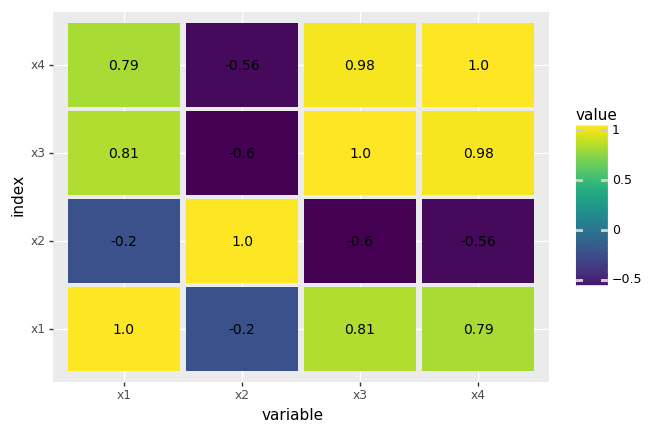

<ggplot: (-9223363269860512480)>

In [7]:
from handyman import get_num_corr_plot
get_num_corr_plot(df2,  ['x1', 'x2', 'x3', 'x4'])

### import classification_metrics

In [8]:
from handyman import classification_metrics
classification_metrics(y, LogisticRegression().fit(X, y).predict(X))

OrderedDict([('accuracy', 1.0), ('roc_auc', 1.0), ('f1_score', 1.0)])

### kaiser_harris_criterion

In [9]:
from handyman import kaiser_harris_criterion
kaiser_harris_criterion(X)

1

### serialize_model & unserialize_model

In [10]:
from handyman import serialize_model, unserialize_model

clf_lr = LogisticRegression().fit(X, y)
model_df = serialize_model(clf_lr, 'Example')
model_df

,model_type,description,params,attrs
0,LogisticRegression,Example,"{""C"": 1.0, ""class_weight"": null, ""dual"": false...","{""classes_"": [0, 1], ""coef_"": [[-0.40731745112..."


In [11]:
clf_lr_reconstructed = unserialize_model(model_df, LogisticRegression())
print(clf_lr_reconstructed)
print(clf_lr_reconstructed.score(X, y))

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)
1.0


### rf_feature_importance

In [12]:
from handyman import rf_feature_importance

clf_rf = RandomForestClassifier().fit(df2.iloc[:,[0, 1, 2, 3]], df2.target.values)
rf_feature_importance(df2.iloc[:,[0, 1, 2, 3]], clf_rf)

[('x3', 0.5353168354108213),
 ('x4', 0.3275197798417613),
 ('x1', 0.12598026838565796),
 ('x2', 0.01118311636175948)]

### flatten_dict

In [13]:
from handyman import flatten_dict

flatten_dict(
    {'Name':'John', 'Location':{'City':'Los Angeles','State':'CA'}, 'hobbies':['Music', 'Running']}
)

{'Name': 'John',
 'Location_City': 'Los Angeles',
 'Location_State': 'CA',
 'hobbies_0': 'Music',
 'hobbies_1': 'Running'}

### get_coefficients

In [14]:
from handyman import get_coefficients
get_coefficients(df2.iloc[:,[0, 1, 2, 3]], clf_lr)

,feature,coefficient
0,x3,2.240047
1,x4,1.008415
2,x1,-0.407317
3,x2,-1.460924


### get_date_time

In [15]:
from handyman import get_date_time
get_date_time()

['2018-06-21', '01:39:17.546189']